In [1]:
# ==============================================================================
# IMPORTS_AND_PATHS
# ==============================================================================
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../src'))

from data_preprocessing import preprocess_pipeline
from model_detection import DetectionModel
from model_cause import CauseModel
from model_prediction import PredictionModel
from train_evaluate import train_detection_model, train_cause_model, train_prediction_model, calculate_classification_metrics, calculate_regression_metrics

In [2]:
# ==============================================================================
# DATA_LOADING_AND_PREPROCESSING
# ==============================================================================
FILE_PATH = '../data/industrial_dataset.csv'

(
    x_train_bal, x_val, x_test,
    y_stop_train_bal, y_stop_val, y_stop_test,
    y_cause_train_bal, y_cause_val, y_cause_test,
    y_time_train_bal, y_time_val, y_time_test,
    preprocessing_params
) = preprocess_pipeline(FILE_PATH)

WINDOW_SIZE = preprocessing_params['window_size']
N_FEATURES = x_train_bal.shape[2]

In [3]:
# ==============================================================================
# MODEL_INITIALIZATION
# ==============================================================================
HIDDEN_SIZE = 32
ATTENTION_SIZE = 16
NUM_CAUSES = 4

detection_model = DetectionModel(input_size=N_FEATURES, hidden_size=HIDDEN_SIZE, attention_size=ATTENTION_SIZE)
cause_model = CauseModel(input_size=N_FEATURES, hidden_size=HIDDEN_SIZE, attention_size=ATTENTION_SIZE, num_classes=NUM_CAUSES)
prediction_model = PredictionModel(input_size=N_FEATURES, hidden_size=HIDDEN_SIZE, attention_size=ATTENTION_SIZE)

In [4]:
# ==============================================================================
# HYPERPARAMETERS_AND_TRAINING
# ==============================================================================
EPOCHS = 5
LEARNING_RATE = 0.01

print("--- DETECCION ---")
det_train_loss, det_val_loss = train_detection_model(
    detection_model, x_train_bal, y_stop_train_bal, x_val, y_stop_val, EPOCHS, LEARNING_RATE
)

print("\n--- CAUSA ---")
cause_train_loss = train_cause_model(
    cause_model, x_train_bal, y_cause_train_bal, EPOCHS, LEARNING_RATE
)

print("\n--- PREDICCION TEMPORAL ---")
pred_train_loss = train_prediction_model(
    prediction_model, x_train_bal, y_time_train_bal, EPOCHS, LEARNING_RATE
)

--- DETECCION ---
Epoch 1/5 | Train Loss: 0.1574 | Val Loss: 0.0298
Epoch 2/5 | Train Loss: 0.0286 | Val Loss: 0.0398
Epoch 3/5 | Train Loss: 0.0211 | Val Loss: 0.0461
Epoch 4/5 | Train Loss: 0.0237 | Val Loss: 0.0451
Epoch 5/5 | Train Loss: 0.0196 | Val Loss: 0.0427

--- CAUSA ---
Epoch 1/5 | Cause Train Loss: 0.3819
Epoch 2/5 | Cause Train Loss: 0.2097
Epoch 3/5 | Cause Train Loss: 0.1709
Epoch 4/5 | Cause Train Loss: 0.1627
Epoch 5/5 | Cause Train Loss: 0.1606

--- PREDICCION TEMPORAL ---
Epoch 1/5 | Pred Train Loss: 0.0311
Epoch 2/5 | Pred Train Loss: 0.0280
Epoch 3/5 | Pred Train Loss: 0.0269
Epoch 4/5 | Pred Train Loss: 0.0262
Epoch 5/5 | Pred Train Loss: 0.0256


In [5]:
# ==============================================================================
# MODEL_EVALUATION
# ==============================================================================
y_pred_det_list = []
for i in range(len(x_test)):
    pred, _ = detection_model.forward_pass(x_test[i])
    y_pred_det_list.append(pred)
    
y_pred_det = np.array(y_pred_det_list)
accuracy, precision, recall, f1_score = calculate_classification_metrics(y_stop_test, y_pred_det)

print("--- EVALUACION MODULO A (DETECCION) ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")

mask_test = y_stop_test > 0
if np.sum(mask_test) > 0:
    x_test_causes = x_test[mask_test]
    y_test_causes = y_cause_test[mask_test] - 1
    
    correct_causes = 0
    for i in range(len(x_test_causes)):
        pred_probs, _ = cause_model.forward_pass(x_test_causes[i])
        pred_cause = np.argmax(pred_probs)
        if pred_cause == int(y_test_causes[i]):
            correct_causes += 1
            
    cause_accuracy = correct_causes / len(x_test_causes)
    print(f"\n--- EVALUACION MODULO B (CAUSA) ---")
    print(f"Accuracy de Causa: {cause_accuracy:.4f}")

y_pred_time_list = []
for i in range(len(x_test)):
    pred_time, _ = prediction_model.forward_pass(x_test[i])
    y_pred_time_list.append(pred_time)

y_pred_time = np.array(y_pred_time_list)
mae, rmse = calculate_regression_metrics(y_time_test, y_pred_time, preprocessing_params['max_time'])

print(f"\n--- EVALUACION MODULO C (PREDICCION) ---")
print(f"MAE (Segundos de error promedio): {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

--- EVALUACION MODULO A (DETECCION) ---
Accuracy:  0.9897
Precision: 0.1515
Recall:    0.6250
F1-Score:  0.2439

--- EVALUACION MODULO B (CAUSA) ---
Accuracy de Causa: 0.6250

--- EVALUACION MODULO C (PREDICCION) ---
MAE (Segundos de error promedio): 267.5433
RMSE: 305.3508


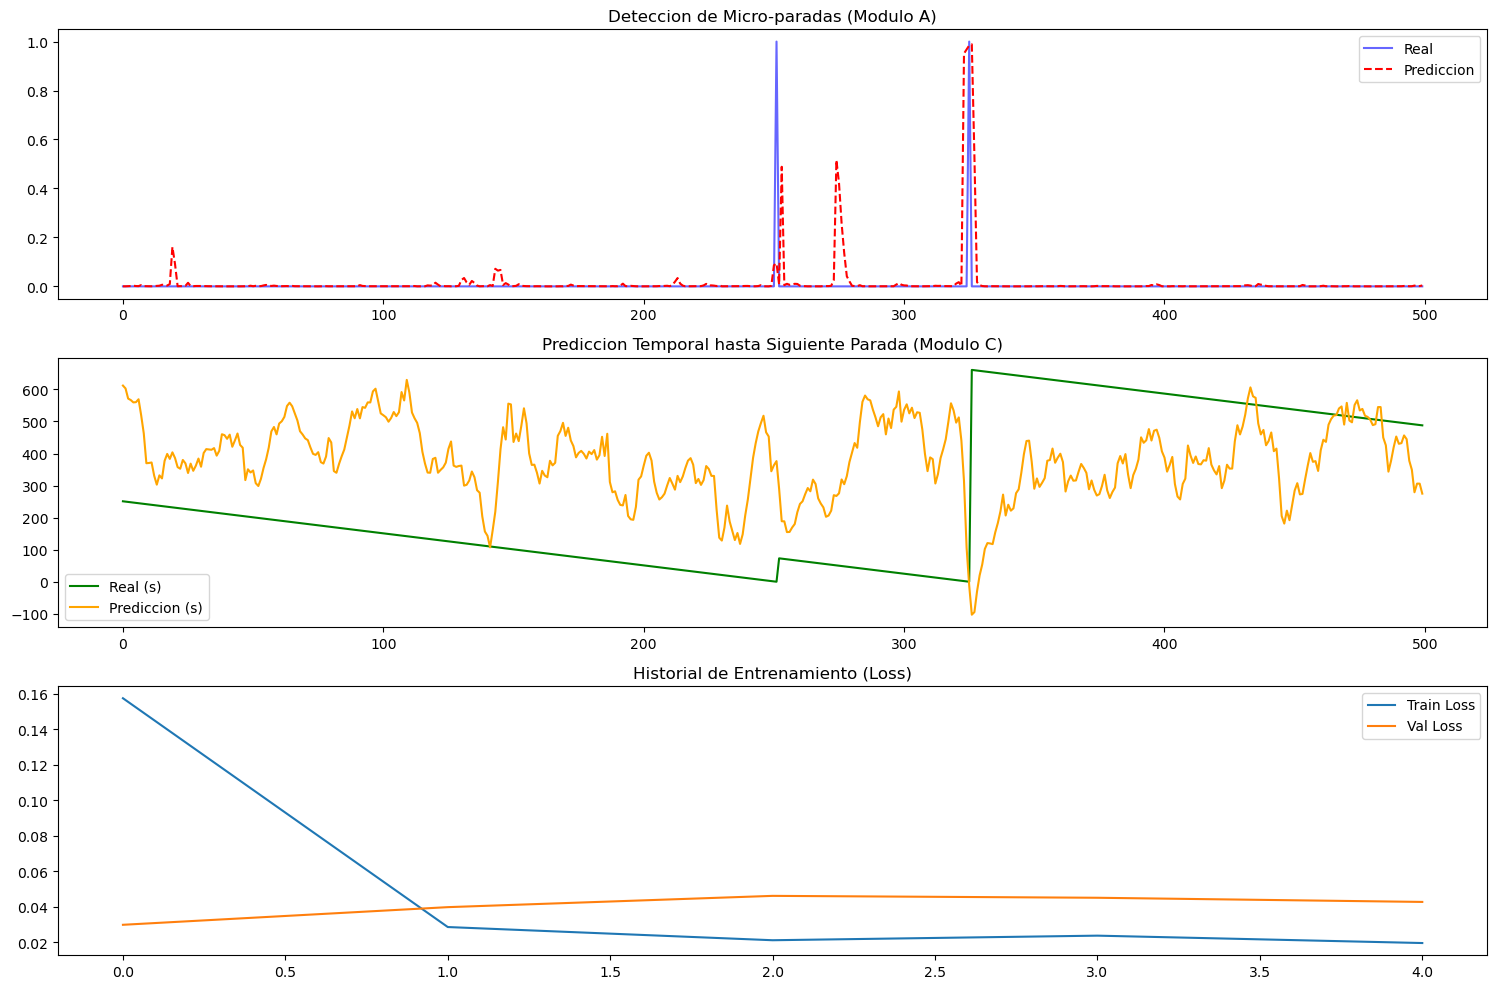

In [6]:
# ==============================================================================
# VISUALIZATION
# ==============================================================================
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(y_stop_test[:500], label='Real', color='blue', alpha=0.6)
plt.plot(y_pred_det[:500], label='Prediccion', color='red', linestyle='--')
plt.title('Deteccion de Micro-paradas (Modulo A)')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(y_time_test[:500] * preprocessing_params['max_time'], label='Real (s)', color='green')
plt.plot(y_pred_time[:500] * preprocessing_params['max_time'], label='Prediccion (s)', color='orange')
plt.title('Prediccion Temporal hasta Siguiente Parada (Modulo C)')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(det_train_loss, label='Train Loss')
plt.plot(det_val_loss, label='Val Loss')
plt.title('Historial de Entrenamiento (Loss)')
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
# ==============================================================================
# DOWNTIME_IMPACT_SIMULATION
# ==============================================================================
COSTO_POR_SEGUNDO_PARADA = 50 
TIEMPO_PROMEDIO_PARADA = 5 

total_paradas_reales = np.sum(y_stop_test)
paradas_detectadas = recall * total_paradas_reales

downtime_total_sin_ia = total_paradas_reales * TIEMPO_PROMEDIO_PARADA
downtime_con_ia = (total_paradas_reales - paradas_detectadas) * TIEMPO_PROMEDIO_PARADA

ahorro_economico = (downtime_total_sin_ia - downtime_con_ia) * COSTO_POR_SEGUNDO_PARADA

print("--- SIMULACION DE IMPACTO ECONOMICO ---")
print(f"Total de micro-paradas en test: {total_paradas_reales}")
print(f"Reduccion de Downtime estimada: {((downtime_total_sin_ia - downtime_con_ia) / downtime_total_sin_ia) * 100:.2f}%")
print(f"Ahorro economico estimado: ${ahorro_economico:,.2f} USD")

--- SIMULACION DE IMPACTO ECONOMICO ---
Total de micro-paradas en test: 8.0
Reduccion de Downtime estimada: 62.50%
Ahorro economico estimado: $1,250.00 USD
